Import af data:

In [32]:
import pandas as pd

path = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\processed\A\global_test_set_non-iid.csv"
df = pd.read_csv(path)
df

,Client,Patient,Age,Sex,Pain,Swelling,Trismus,Pericoronitis,Caries_Wisdom,Caries_Adjacent,...,Risk_SecondaryInfection_Prob,Risk_NerveDysesthesia,Risk_NerveDysesthesia_Prob,Risk_Bleeding,Risk_Bleeding_Prob,Risk_Category_AlveolarOsteitis,Risk_Category_SecondaryInfection,Risk_Category_NerveDysesthesia,Risk_Category_Bleeding,Risk_Category_Composite
0,2,10,31,0,1,0,0,0,0,0,...,0.07875,0,0.001069,0,0.00735,1,2,1,2,2
1,5,18,30,1,1,1,0,1,0,0,...,0.06300,0,0.014850,0,0.00700,2,2,2,2,2
2,5,20,18,1,0,1,0,0,1,0,...,0.03780,0,0.000146,0,0.00210,0,1,0,0,1
3,9,49,30,0,0,1,0,0,0,0,...,0.02730,0,0.001069,0,0.00399,1,1,1,1,1
4,7,78,25,0,0,1,0,0,0,0,...,0.01890,0,0.000445,0,0.00210,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,10,4969,33,0,1,1,0,0,0,0,...,0.06300,0,0.005940,0,0.00700,2,2,2,2,2
2996,2,4972,33,1,0,1,1,0,1,0,...,0.03185,0,0.002376,0,0.00570,2,1,1,1,2
2997,5,4973,31,0,0,0,0,0,0,1,...,0.06300,0,0.014850,0,0.00700,2,2,2,2,2
2998,5,4980,25,1,0,0,0,1,0,1,...,0.04200,0,0.005940,0,0.00700,2,1,2,2,2


Vi tilføjer en kolonne som er 1 hvis man har fået mindt 1 komplication:

In [50]:
df[df["Risk_SecondaryInfection"] == 1]["Risk_SecondaryInfection"]
df["Complication"] = ((df["Risk_SecondaryInfection"] == 1) | (df["Risk_NerveDysesthesia"]==1) | (df["Risk_Bleeding"] == 1) | (df["Risk_Category_AlveolarOsteitis"]==1)).astype(int)

Vi laver en simple lineær regression på alder om den binære komplication:

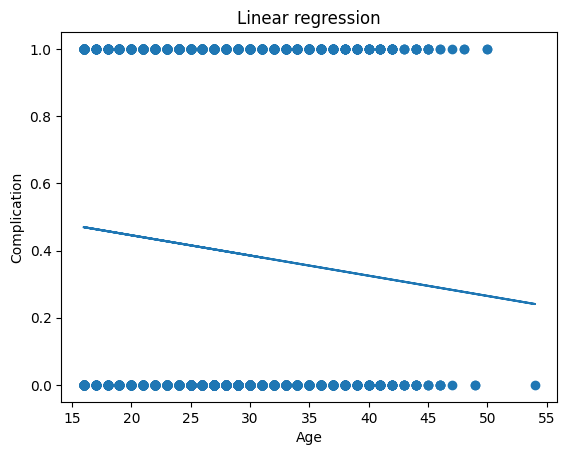

Slope: -0.006019388543300819
Intercept: 0.5658476786066633


In [25]:
import numpy as np
import matplotlib.pyplot as plt

x = df["Age"]
y = df["Complication"]

# lineær regression
slope, intercept = np.polyfit(x, y, 1)

# regression linje
y_pred = slope * x + intercept

# plot
plt.scatter(x, y)
plt.plot(x, y_pred)

plt.xlabel("Age")
plt.ylabel("Complication")
plt.title("Linear regression")

plt.show()

print("Slope:", slope)
print("Intercept:", intercept)

To inverstergate the federated setup, we explore the Federated linear regression:

In [80]:
import numpy as np
import matplotlib.pyplot as plt

coef = np.zeros((10,4))

for i in range(1,11):
    client_data = df[df["Client"] == i]
    x = client_data["Age"]
    y = client_data["Complication"]
    if len(client_data) != 0:
        slope, intercept = np.polyfit(x, y, 1)
        coef[i-1][1] = slope
        coef[i-1][2] = intercept    
    coef[i-1][0] = int(i)
    coef[i-1][3] = len(client_data)
    

#Aggregering (Simpelt mean):

print("Aggregated coef simple mean (slope, intercept):")
coef_agg = np.mean(coef[:,1:3], axis = 0)
print(coef_agg)

coef_agg_weigted_intercept = 0
coef_agg_weigted_slope = 0
total_data = len(df)
for i in range(10):
    coef_agg_weigted_intercept += coef[i][3]/total_data * coef[i][2]
    coef_agg_weigted_slope += coef[i][3]/total_data * coef[i][1]

print("Aggregated coef weighted mean:")
print("Slope:",coef_agg_weigted_slope, "Intercept:",coef_agg_weigted_intercept)




Aggregated coef simple mean (slope, intercept):
[0.00970265 0.14646741]
Aggregated coef weighted mean:
Slope: -0.005473635238349027 Intercept: 0.5578799986254092
